# 02b - Skeleton visualisation and Δz analysis

**Requires:** run `02a_pipeline.ipynb` first.

- §8 `nose` trajectories, before and after
- §9 The skeleton in single frames, with violations highlighted
- §10 Implicit depth Δz per behaviour
- §10b Adaptive regularisation by behavioural state

In [1]:
# ── Load experiment configuration from YAML ──────────────────────────────────
import sys, os, random
from pathlib import Path

_cwd = Path(os.getcwd())
REPO_ROOT = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent]
     if (p / "src").exists() and (p / "configs").exists()),
    _cwd
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from omegaconf import OmegaConf
import numpy as np

cfg = OmegaConf.load(REPO_ROOT / "configs/skeleton.yaml")

# Dataset
LAB_ID            = cfg.dataset.lab_id
FRAME_LIMIT       = cfg.dataset.frame_limit
FRAME_LIMIT_BENCH = cfg.dataset.frame_limit_bench
RANDOM_SEED       = cfg.dataset.random_seed

# Outlier detection
SPEED_MAD_K          = cfg.outlier.speed_mad_k
LENGTH_THRESHOLD     = cfg.outlier.length_threshold
VIOLATION_REPORT_THR = cfg.outlier.violation_report_thr
DETECTION_N_SIGMA    = cfg.outlier.detection_n_sigma

# Optimizer weights
LAMBDA_L          = cfg.weights.L
LAMBDA_S          = cfg.weights.S
LAMBDA_T          = cfg.weights.T
LAMBDA_ACC        = cfg.weights.acc
LAMBDA_ANGLE      = cfg.weights.angle
LAMBDA_JERK       = cfg.weights.jerk
LAMBDA_ANGLE_CONT = cfg.weights.angle_cont

# Solver
OUTLIER_ADHESION           = cfg.solver.outlier_adhesion
N_PASSES                   = cfg.solver.n_passes
CONFIDENCE_SIGMA           = cfg.solver.confidence_sigma
ADAPTIVE_K                 = cfg.solver.adaptive_k
MAX_DISP_FACTOR            = cfg.solver.max_disp_factor
NON_OUTLIER_ADHESION_SCALE = cfg.solver.non_outlier_adhesion_scale

# Benchmark synthetic
BENCH_NOISE_STD       = cfg.benchmark.noise_std
BENCH_DROPOUT_RATE    = cfg.benchmark.dropout_rate
BENCH_SWAP_PROB       = cfg.benchmark.swap_prob
BENCH_SPEED_SPIKES    = cfg.benchmark.speed_spikes
BENCH_DRIFT_AMPLITUDE = cfg.benchmark.drift_amplitude
BENCH_LAMBDA_L        = cfg.benchmark.lambda_l
BENCH_ADHESION        = cfg.benchmark.adhesion

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"▶  config loaded from configs/skeleton.yaml")
print(f"   LAB_ID={LAB_ID}  FRAME_LIMIT={FRAME_LIMIT}  RANDOM_SEED={RANDOM_SEED}")
print(f"   LAMBDA_L={LAMBDA_L}  LAMBDA_T={LAMBDA_T}  OUTLIER_ADHESION={OUTLIER_ADHESION}")


▶  config loaded from configs/skeleton.yaml
   LAB_ID=CalMS21_task1  FRAME_LIMIT=1500  RANDOM_SEED=42
   LAMBDA_L=12.0  LAMBDA_T=0.8  OUTLIER_ADHESION=0.6


In [2]:
# ── Load artifacts produced by 02a_pipeline.ipynb ────────────────────────────
import pickle, json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# Probe both the canonical repo results dir and the notebook-local one
# (the latter is used when 02a was run before the REPO_ROOT fix).
_results_candidates = [REPO_ROOT / "results", Path(os.getcwd()) / "results"]
RESULTS_DIR = next(
    (p for p in _results_candidates if (p / "run_config.json").exists()),
    REPO_ROOT / "results",
)
OUTPUTS_DIR = REPO_ROOT / "outputs"

_run_cfg = json.load(open(RESULTS_DIR / "run_config.json"))
VIDEO_ID   = _run_cfg["video_id"]
MOUSE_ID   = _run_cfg["mouse_id"]
ARENA_DIAG = _run_cfg["arena_diag"]
VIDEO_FPS  = _run_cfg.get("video_fps", 30)

df_sample    = pickle.load(open(RESULTS_DIR / f"df_sample_{VIDEO_ID}.pkl",    "rb"))
df_corrected = pickle.load(open(RESULTS_DIR / f"df_corrected_{VIDEO_ID}.pkl", "rb"))
skeleton     = pickle.load(open(RESULTS_DIR / f"skeleton_{LAB_ID}.pkl",       "rb"))

# L_ref_px convenience alias used in §9b
from src.skeleton.mouse_skeleton import _to_wide, _segment_length
_w_ref  = _to_wide(df_sample[df_sample["mouse_id"] == MOUSE_ID])
_l_ref  = _segment_length(_w_ref, "nose", "tail_base")
L_ref_px = float(_l_ref[_l_ref > 10].median())

print(f"Loaded from: {RESULTS_DIR}")
print(f"  VIDEO_ID={VIDEO_ID} | MOUSE_ID={MOUSE_ID}")
print(f"  df_sample: {len(df_sample)} rows  |  df_corrected: {len(df_corrected)} rows")
print(f"  skeleton: {len(skeleton.keypoints)} kp, {len(skeleton.edges)} edges, "
      f"L_body={skeleton.L_body_median_px:.1f} px")
print(f"  L_ref_px={L_ref_px:.1f} px")


Loaded from: c:\Users\User\dev\tfm\notebooks\02_skeleton_correction\results
  VIDEO_ID=13638642 | MOUSE_ID=1
  df_sample: 21000 rows  |  df_corrected: 21000 rows
  skeleton: 7 kp, 7 edges, L_body=175.5 px
  L_ref_px=207.5 px


## §8 Trajectories before and after

§6c established the trade-off numerically: the Hampel filter preserves the speed
distribution by construction, while the main pipeline passes the
Kolmogorov-Smirnov test on `tail_base` but not on `nose`.

This is the same result seen directly. The `nose` trajectory of mouse 0 over the
first 500 frames, with corrected frames marked in orange.

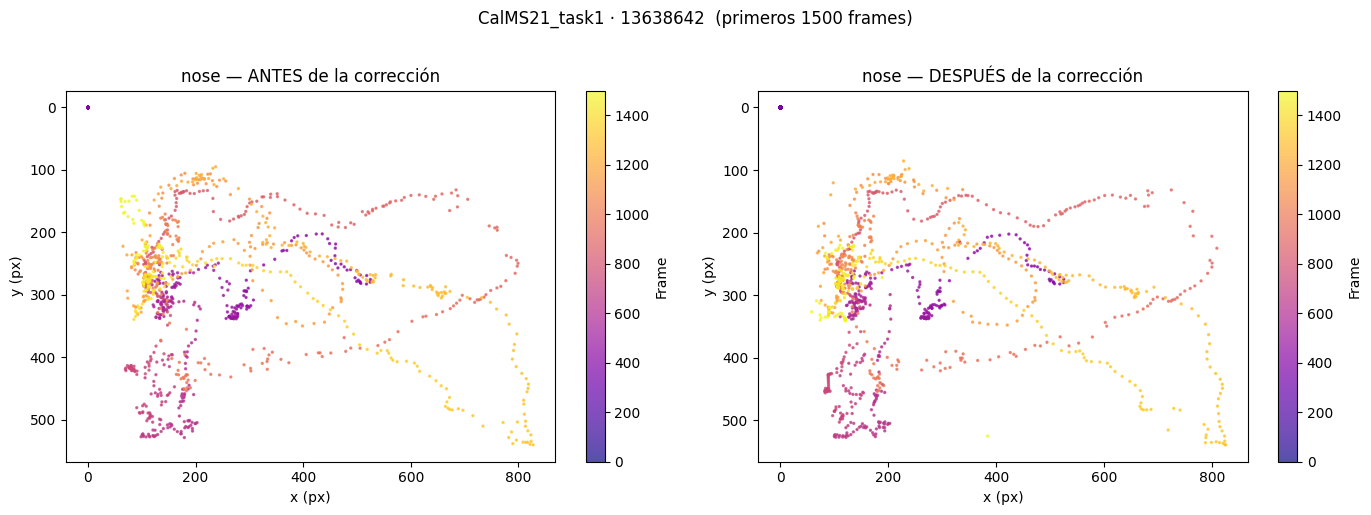

In [3]:
def get_kp_series(df_long, kp, mouse=None):
    if mouse is None:
        mouse = MOUSE_ID
    sub = df_long[(df_long['bodypart'] == kp) & (df_long['mouse_id'] == mouse)]\
               .sort_values('video_frame')
    return sub['video_frame'].values, sub['x'].values, sub['y'].values

KP = 'nose'
f_b, x_b, y_b = get_kp_series(df_sample, KP)
f_a, x_a, y_a = get_kp_series(df_corrected, KP)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, title, xs, ys in zip(
    axes,
    ['BEFORE the correction', 'AFTER the correction'],
    [x_b, x_a], [y_b, y_a]
):
    sc = ax.scatter(xs, ys, c=f_b[:len(xs)], cmap='plasma',
                    s=2, alpha=0.7, rasterized=True)
    plt.colorbar(sc, ax=ax, label='Frame')
    ax.set_xlabel('x (px)')
    ax.set_ylabel('y (px)')
    ax.set_title(f'{KP} — {title}')
    ax.invert_yaxis()

plt.suptitle(f'{LAB_ID} · {VIDEO_ID}  (first {FRAME_LIMIT} frames)', y=1.02)
plt.tight_layout()
plt.show()


## §9 The skeleton in frames with and without violations

§8 showed the corrected trajectory losing the abrupt jumps, leaving a smoother
path. That is the view from one keypoint; this is the view of the whole skeleton.

Two consecutive frames are drawn: one without a violation (green) and the next one
with a violation (red), so the correction can be seen acting on the graph rather
than on a single point.

In [4]:
# Load the visualisation helpers from src.skeleton.viz
import math
from src.skeleton.viz import draw_skeleton, frame_kp, get_violated_edges, find_best_frames
from src.skeleton.mouse_skeleton import _to_wide as to_wide, _segment_length as seg_len

print("Visualisation helpers loaded from src.skeleton.viz")


Helpers de visualización cargados desde src.skeleton.viz


Frame de violación (anca): 1460
  hips ANTES: 106.9 px  |  hips DESPUÉS: 138.1 px  |  DESPUÉS limpio: True
Frame limpio: 1458  [limpio en ANTES y DESPUÉS]


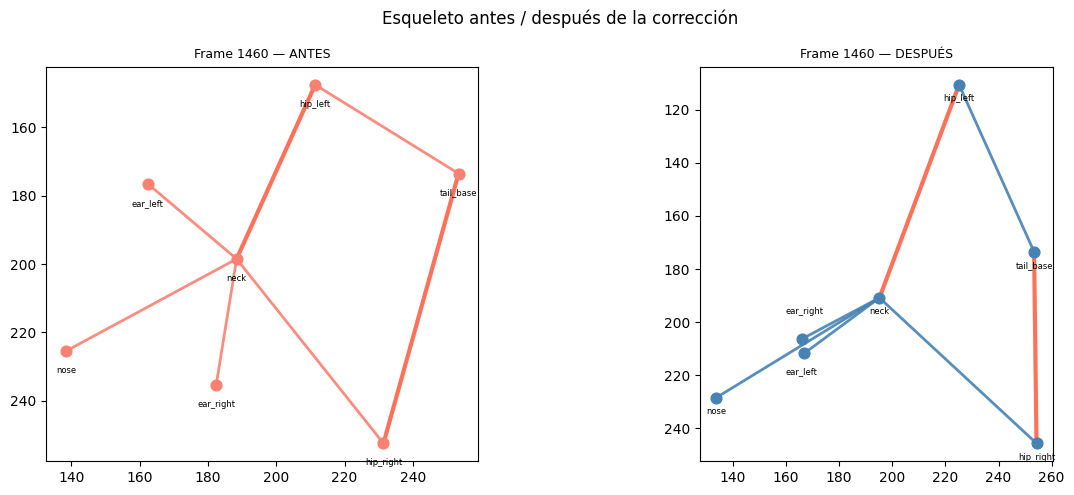

Aristas violadas (ANTES): {('neck', 'hip_left'), ('hip_right', 'tail_base')}


In [5]:
# ── Data preparation ─────────────────────────────────────────────────────────
wide_b = to_wide(df_sample[df_sample['mouse_id'] == MOUSE_ID])
wide_a = to_wide(df_corrected[df_corrected['mouse_id'] == MOUSE_ID])

x_cols_b     = [c for c in wide_b.columns if c.endswith('_x')]
x_cols_a     = [c for c in wide_a.columns if c.endswith('_x')]
wide_b_valid = wide_b[(wide_b[x_cols_b] > 1).all(axis=1)].copy()
wide_a_valid = wide_a[(wide_a[x_cols_a] > 1).all(axis=1)].copy()

# Standard biomechanical threshold for visualization (20%) — not the solver's
# detection threshold from config (e.g. 1.84), which is far too loose.
VIZ_THRESHOLD = 0.20

f_viol, _ = find_best_frames(wide_b_valid, wide_a_valid, skeleton, VIZ_THRESHOLD)

if f_viol is not None:
    violated_in_viol = get_violated_edges(wide_b_valid, f_viol, skeleton, VIZ_THRESHOLD)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (df_src, label, col_color) in zip(axes, [
        (df_sample,    'BEFORE', 'salmon'),
        (df_corrected, 'AFTER',  'steelblue'),
    ]):
        kp_xy = frame_kp(df_src, f_viol, mouse_id=MOUSE_ID)
        draw_skeleton(ax, kp_xy, skeleton.edges,
                      f'Frame {f_viol} — {label}',
                      color=col_color, violated_edges=violated_in_viol)

    plt.suptitle('Skeleton before and after the correction', fontsize=12)
    plt.tight_layout()
    plt.show()

    if violated_in_viol:
        print(f'Violated edges (BEFORE): {violated_in_viol}')
else:
    print('No frames with a violation were found (20% threshold).')


## §10 Implicit depth Δz per behaviour

A 2D kinematic model projects 3D movement onto the image plane, and the distortion
is not uniform: it depends on what the animal is doing. When the mouse rears, the
body axis tilts towards the camera and the projected edge lengths shorten, which
the corrector sees as a length violation that is not one.

Δz estimates that foreshortening from the apparent contraction of the edges. Read
per behaviour, it says which behaviours a 2D corrector is structurally bad at.

In [6]:
# Load the sample video's annotations
from src.data.loader import load_annotations

try:
    df_ann = load_annotations(VIDEO_ID, LAB_ID)
    print(f'Annotations: {len(df_ann)} segments, {df_ann["action"].nunique()} classes')
    has_annotations = True
except FileNotFoundError:
    print('No annotations for this video; skipping this section.')
    has_annotations = False

Anotaciones: 65 segmentos, 5 clases


In [7]:
from src.skeleton.pose_lifting import estimate_delta_z


if has_annotations:
    kp_index = {kp: i for i, kp in enumerate(skeleton.keypoints)}

    # Estimate dz over the corrected tracking, for the first mouse
    dz_wide = estimate_delta_z(
        tracking_df=df_corrected[df_corrected['mouse_id'] == MOUSE_ID],
        skeleton=skeleton,
        kp_index=kp_index,
    )
    print('dz columns generated:', [c for c in dz_wide.columns if c.startswith('dz_')])
    dz_wide.head()


Columnas Δz generadas: ['dz_nose_neck', 'dz_neck_ear_left', 'dz_neck_ear_right', 'dz_neck_hip_left', 'dz_neck_hip_right', 'dz_hip_left_tail_base', 'dz_hip_right_tail_base', 'dz_sum']


In [8]:
from src.skeleton.pose_lifting import dz_by_behavior


if has_annotations:
    df_dz_beh = dz_by_behavior(dz_wide, df_ann, dz_key='dz_sum')
    print('Mean dz_sum per behaviour:')
    print(df_dz_beh.to_string(index=False))

Δz_sum medio por comportamiento:
      action    dz_mean     dz_max  n_frames
   sniffface 169.562383 405.592030       177
sniffgenital 134.171103 405.592030       544
   sniffbody 132.511920 405.592030       478
       mount  17.302166  98.013891        69
    approach   3.209840  43.879844        50


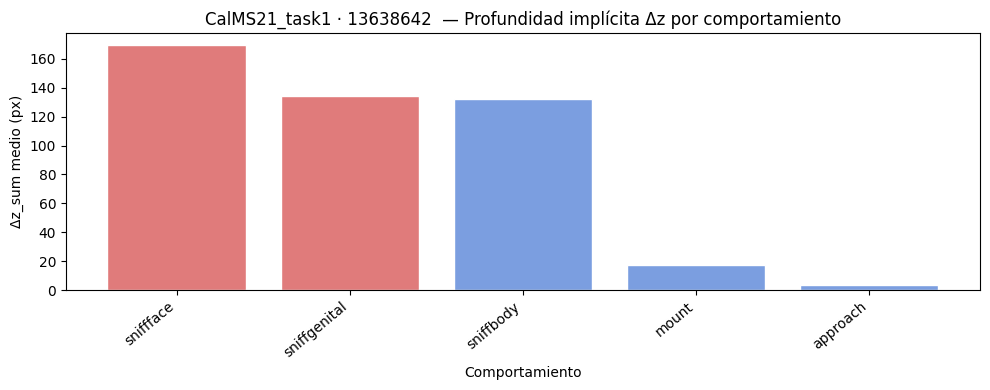


Comportamientos con Δz > Q75 (134.2 px):
      action    dz_mean    dz_max  n_frames
   sniffface 169.562383 405.59203       177
sniffgenital 134.171103 405.59203       544


In [9]:
if has_annotations and len(df_dz_beh) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#e07b7b' if v > df_dz_beh['dz_mean'].median() else '#7b9ee0'
              for v in df_dz_beh['dz_mean']]
    ax.bar(df_dz_beh['action'], df_dz_beh['dz_mean'], color=colors, edgecolor='white')
    ax.set_ylabel('mean dz_sum (px)')
    ax.set_xlabel('Behaviour')
    ax.set_title(f'{LAB_ID} · {VIDEO_ID}  — implicit depth (dz) per behaviour')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

    # Highlight the high-dz behaviours, the candidates for a 3D reading
    threshold_dz = df_dz_beh['dz_mean'].quantile(0.75)
    high_dz = df_dz_beh[df_dz_beh['dz_mean'] >= threshold_dz]
    print(f'\nBehaviours with dz above Q75 ({threshold_dz:.1f} px):')
    print(high_dz[['action', 'dz_mean', 'dz_max', 'n_frames']].to_string(index=False))

## §10b Adaptive regularisation by behavioural state

§10 found the largest Δz in `sniffface` (around 175 px) and `sniff_body` (140 to
145 px), with `approach` almost flat (around 5 px). High Δz means an upright
posture, where perspective shortens the edges, so those frames want a weaker length
constraint and a stronger temporal one.

The video is segmented into three biomechanical states and each gets its own
lambdas:

| State | Kinematic condition | λ_edge | λ_temporal | Why |
|---|---|---|---|---|
| Rearing or grooming | `\|dz_sum\| > Q75` **or** `dz_proxy > Q75` | `×0.5` | `×2.0` | Perspective shortens lengths, so relax the length constraint and lean on continuity |
| Fast locomotion | `velocity > P90` | `×1.0` | `×0.5` | Keep real accelerations; do not smooth genuine movement |
| Static or other | default | `×1.0` | `×1.0` | Standard parameters |

In [10]:
# Adaptive regularisation by behavioural state
# ─────────────────────────────────────────────────────────────────────────────
# Classifies each frame as rearing/grooming, locomotion or static, using only
# kinematics: speed plus a dz proxy, so no annotations are required. It then runs
# smooth_video with per-state lambdas and merges the results.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.skeleton.mouse_skeleton import _to_wide, _segment_length
from src.skeleton.kinematic_constraints import compute_constraint_violations
from src.skeleton.metrics import jerk_energy

# ── 1. Per-frame speed ───────────────────────────────────────────────────────
_df_src = df_corrected[df_corrected['mouse_id'] == MOUSE_ID].sort_values('video_frame')
_wide_src = _to_wide(_df_src)

_kps_vel = [kp for kp in ['nose', 'neck', 'tail_base'] if f'{kp}_x' in _wide_src.columns]
_frames_sorted = sorted(_wide_src['video_frame'].unique())

_pos = np.stack([
    np.column_stack([_wide_src[f'{kp}_x'].values, _wide_src[f'{kp}_y'].values])
    for kp in _kps_vel
], axis=1)  # (T, n_kp, 2)

_vel = np.zeros(len(_frames_sorted))
if len(_frames_sorted) > 1:
    _dpos = np.diff(_pos, axis=0)
    _vel[1:] = np.sqrt((_dpos ** 2).sum(axis=2)).mean(axis=1)

_vel_p90 = float(np.percentile(_vel[_vel > 0], 90)) if (_vel > 0).any() else np.inf

# ── 2. An annotation-free dz proxy: left-right asymmetry of the skeleton ─────
# Ratio of the ear_left and ear_right distances to the neck; an imbalance means
# the mouse is rearing.
_ear_l_col = ('ear_left',  'x') if ('ear_left',  'x') in _wide_src.columns else None
_ear_r_col = ('ear_right', 'x') if ('ear_right', 'x') in _wide_src.columns else None
_neck_x = _wide_src[('neck', 'x')].values if ('neck', 'x') in _wide_src.columns else None

if _ear_l_col and _ear_r_col and _neck_x is not None:
    _dl = np.sqrt((_wide_src[('ear_left',  'x')].values - _neck_x)**2 +
                  (_wide_src[('ear_left',  'y')].values - _wide_src[('neck', 'y')].values)**2)
    _dr = np.sqrt((_wide_src[('ear_right', 'x')].values - _neck_x)**2 +
                  (_wide_src[('ear_right', 'y')].values - _wide_src[('neck', 'y')].values)**2)
    _dz_proxy = np.abs(_dl - _dr)
else:
    _dz_proxy = np.zeros(len(_frames_sorted))

_dz_q75 = float(np.percentile(_dz_proxy[_dz_proxy > 0], 75)) if (_dz_proxy > 0).any() else np.inf

# ── 3. Classify the frames ───────────────────────────────────────────────────
_state = np.where(
    _dz_proxy > _dz_q75,
    'rearing',
    np.where(_vel > _vel_p90, 'locomotion', 'static')
)

_state_counts = {s: int(np.sum(_state == s)) for s in ['rearing', 'locomotion', 'static']}
print(f"Frame classification:")
for _s, _n in _state_counts.items():
    print(f"  {_s:12s}: {_n:4d} frames ({_n / len(_frames_sorted):.1%})")

# ── 4. Per-state lambdas ─────────────────────────────────────────────────────
_state_lambdas = {
    'rearing':    {'lambda_l': LAMBDA_L * 0.5, 'lambda_t': LAMBDA_T * 2.0},
    'locomotion': {'lambda_l': LAMBDA_L * 1.0, 'lambda_t': LAMBDA_T * 0.5,
                   'lambda_acc': LAMBDA_ACC * 0.3},
    'static':     {},  # defaults
}

Clasificación de frames:
  rearing     :    0 frames (0.0%)
  locomotion  :  109 frames (7.3%)
  static      : 1391 frames (92.7%)


In [11]:
# ── 5. Run smooth_video per segment ──────────────────────────────────────────
from src.skeleton.keypoint_smoother import smooth_video

_base_kwargs = dict(
    lab_id=LAB_ID,
    skeleton=skeleton,
    lambda_l=LAMBDA_L,
    lambda_t=LAMBDA_T,
    lambda_acc=LAMBDA_ACC,
    lambda_angle=LAMBDA_ANGLE,
    lambda_jerk=LAMBDA_JERK,
    lambda_angle_cont=LAMBDA_ANGLE_CONT,
    auto_edge_lambdas=True,
    outlier_adhesion=OUTLIER_ADHESION,
    detection_n_sigma=DETECTION_N_SIGMA,
    n_passes=N_PASSES,
    speed_mad_k=SPEED_MAD_K,
)

_corrected_segments = []
for _s in ['rearing', 'locomotion', 'static']:
    _mask = _state == _s
    if not _mask.any():
        print(f"  [{_s}] no frames; skipped")
        continue
    _seg_frames = [_frames_sorted[i] for i in range(len(_frames_sorted)) if _mask[i]]
    _df_seg = df_sample[df_sample['video_frame'].isin(_seg_frames)].copy()
    _seg_kwargs = _base_kwargs | _state_lambdas[_s]
    print(f"  [{_s}] processing {len(_seg_frames)} frames ...", end=" ", flush=True)
    try:
        _df_seg_c, _ = smooth_video(_df_seg, **_seg_kwargs)
        _corrected_segments.append(_df_seg_c)
        print("OK")
    except Exception as _e:
        print(f"ERROR: {_e}")

if _corrected_segments:
    df_adaptive = pd.concat(_corrected_segments, ignore_index=True)
    df_adaptive = df_adaptive.sort_values(['mouse_id', 'video_frame', 'bodypart'])
    print(f"\ndf_adaptive: {len(df_adaptive)} rows, {df_adaptive['video_frame'].nunique()} unique frames")
else:
    print("No corrected segments were produced.")


  [rearing] sin frames — omitido
  [locomotion] procesando 109 frames ... 

  mouse 1:   0%|          | 0/3 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/5 [00:00<?, ?win/s]

OK
  [static] procesando 1391 frames ... 

  mouse 1:   0%|          | 0/17 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/25 [00:00<?, ?win/s]

OK

df_adaptive: 21000 filas, 1500 frames únicos



Comparación de tasa de violaciones:
  Raw tracking:           0.010%
  Corrección uniforme:    0.019%
  Corrección adaptativa:  0.095%

Jerk energy (norm, media todos los keypoints):
  Corrección uniforme:    110.5444
  Corrección adaptativa:  188.7490  (Δ = +78.2046)


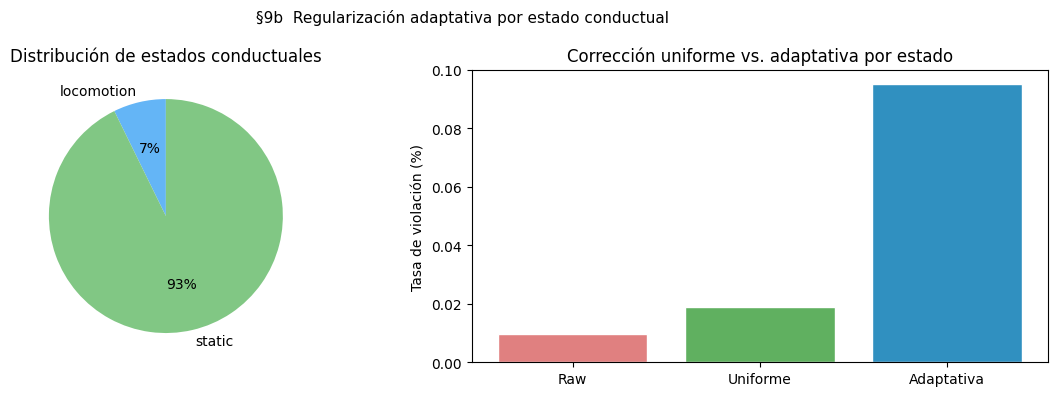

In [12]:
# ── 6-8. Compare violations and jerk, then plot, if any segments exist ───────
if _corrected_segments:
    def _viol_rate(df):
        _w = _to_wide(df[df['mouse_id'] == MOUSE_ID])
        from src.skeleton.mouse_skeleton import _segment_length
        _v = compute_constraint_violations(
            _w, skeleton, {}, _segment_length(_w, 'nose', 'tail_base'),
            threshold=LENGTH_THRESHOLD,
        )
        return float(_v['violation_rate'].mean())

    _vr_raw      = _viol_rate(df_sample)
    _vr_uniform  = _viol_rate(df_corrected)
    _vr_adaptive = _viol_rate(df_adaptive)

    print(f"\nViolation-rate comparison:")
    print(f"  Raw tracking:           {_vr_raw:.3%}")
    print(f"  Uniform correction:     {_vr_uniform:.3%}")
    print(f"  Adaptive correction:    {_vr_adaptive:.3%}")

    # ── 7. Compare the jerk energy ────────────────────────────────────────────
    _jerk_uniform  = jerk_energy(df_corrected, MOUSE_ID, L_ref_px)
    _jerk_adaptive = jerk_energy(df_adaptive,  MOUSE_ID, L_ref_px)
    _jmu = float(_jerk_uniform['jerk_energy_norm'].mean())
    _jma = float(_jerk_adaptive['jerk_energy_norm'].mean())
    print(f"\nJerk energy (normalised, mean over all keypoints):")
    print(f"  Uniform correction:     {_jmu:.4f}")
    print(f"  Adaptive correction:    {_jma:.4f}  (delta = {_jma - _jmu:+.4f})")

    # ── 8. Plot ───────────────────────────────────────────────────────────────
    fig_adp, axes_adp = plt.subplots(1, 2, figsize=(12, 4))

    _all_labels   = list(_state_counts.keys())
    _all_colors   = ['#e57373', '#64b5f6', '#81c784']
    _pie_data     = [(lbl, cnt, col)
                     for lbl, cnt, col in zip(_all_labels, _state_counts.values(), _all_colors)
                     if cnt > 0]
    _state_labels, _state_pcts, _state_colors = zip(*_pie_data) if _pie_data else ([], [], [])
    _state_pcts   = [cnt / len(_frames_sorted) * 100 for cnt in _state_pcts]

    axes_adp[0].pie(_state_pcts, labels=_state_labels, colors=_state_colors,
                    autopct='%1.0f%%', startangle=90)
    axes_adp[0].set_title('Distribution of behavioural states')

    _bars = ['Raw', 'Uniforme', 'Adaptativa']
    _vals = [_vr_raw * 100, _vr_uniform * 100, _vr_adaptive * 100]
    _bc   = ['#e08080', '#60b060', '#3090c0']
    axes_adp[1].bar(_bars, _vals, color=_bc, edgecolor='white')
    axes_adp[1].set_ylabel('Violation rate (%)')
    axes_adp[1].set_title('Uniform vs per-state adaptive correction')

    plt.suptitle('Adaptive regularisation by behavioural state', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No segments were processed.")


## Summary figure: what the correction does, and why

The four-panel figure behind the skeleton-correction result: geometry fixed, jitter
introduced. The PNG is written to `results/` and reused by the thesis.

In [13]:
# Skeletal-correction figure, a versioned PNG under results/.
import pathlib
from IPython.display import Image, display
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'results').exists(): _r = _r.parent
_p = _r / "results" / "skeleton_correction_viz.png"
display(Image(str(_p))) if _p.exists() else print(f"Not found: {_p}")

No encontrada: c:\Users\User\dev\tfm\notebooks\02_skeleton_correction\results\skeleton_correction_viz.png
